## Lab 5: Neural Networks

### Task 1

### 1. Using Dataset 1

In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


Shape of X and y confirms correct tensor conversion

Train-Test Split

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Confirmed dataset is properly split into training and testing sets

Data Visualization Function

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

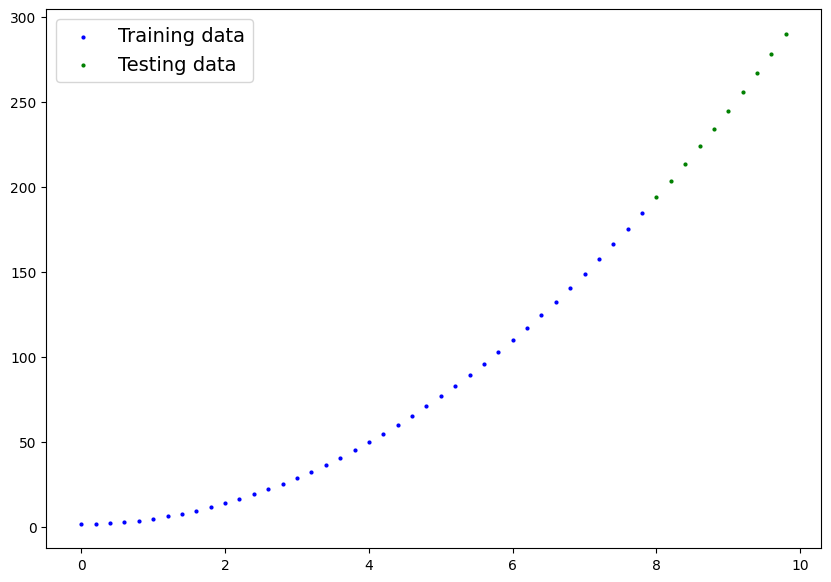

In [ ]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function:
Plots training data (blue),
Plots test data (green),
Optionally plots predictions (red)

Output:
Scatter plot showing dataset distribution
Helps visually understand pattern (quadratic curve)



## Algorithm Selection

In [ ]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [ ]:
model_0 = LinearRegressionNN()

In [ ]:
print(model_0.linear.weight.dtype)
print(model_0.linear.bias.dtype)

torch.float32
torch.float32


In [ ]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579]])

Explanation:

Makes predictions without gradient tracking

Used for evaluation only

Output:

Predictions are inaccurate initially

Red scatter plot does not match real data

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579],
        [7.7109],
        [7.8638],
        [8.0167],
        [8.1696],
        [8.3225]])


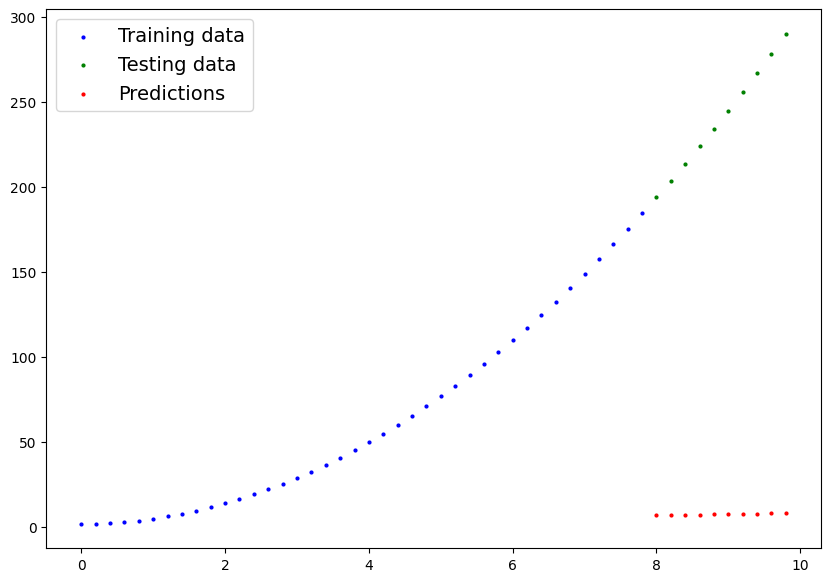

In [ ]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [ ]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 59.80829620361328 | MAE Test Loss: 232.6284942626953 
Epoch: 10 | MAE Train Loss: 58.187294006347656 | MAE Test Loss: 229.0574951171875 
Epoch: 20 | MAE Train Loss: 56.56629180908203 | MAE Test Loss: 225.4864959716797 
Epoch: 30 | MAE Train Loss: 54.945289611816406 | MAE Test Loss: 221.91549682617188 
Epoch: 40 | MAE Train Loss: 53.32429122924805 | MAE Test Loss: 218.34451293945312 
Epoch: 50 | MAE Train Loss: 51.70328903198242 | MAE Test Loss: 214.7734832763672 
Epoch: 60 | MAE Train Loss: 50.12068557739258 | MAE Test Loss: 211.242919921875 
Epoch: 70 | MAE Train Loss: 48.60227584838867 | MAE Test Loss: 207.7753448486328 
Epoch: 80 | MAE Train Loss: 47.13697052001953 | MAE Test Loss: 204.36285400390625 
Epoch: 90 | MAE Train Loss: 45.713233947753906 | MAE Test Loss: 200.9970703125 
Epoch: 100 | MAE Train Loss: 44.328060150146484 | MAE Test Loss: 197.67660522460938 
Epoch: 110 | MAE Train Loss: 42.97723388671875 | MAE Test Loss: 194.39744567871094 
Epoch: 120

Output:

Loss decreases over time

Model gradually learns correct curve

Loss Curve Visualization

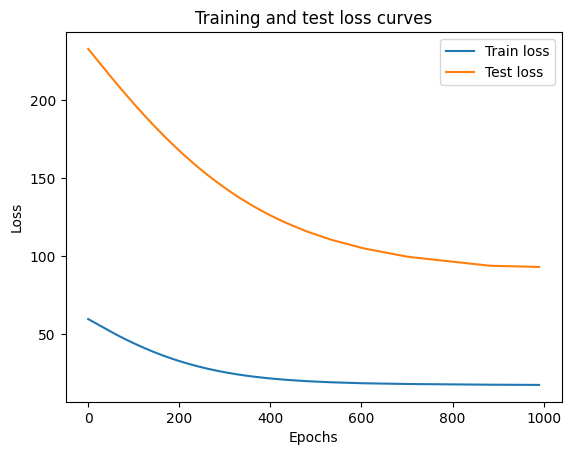

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

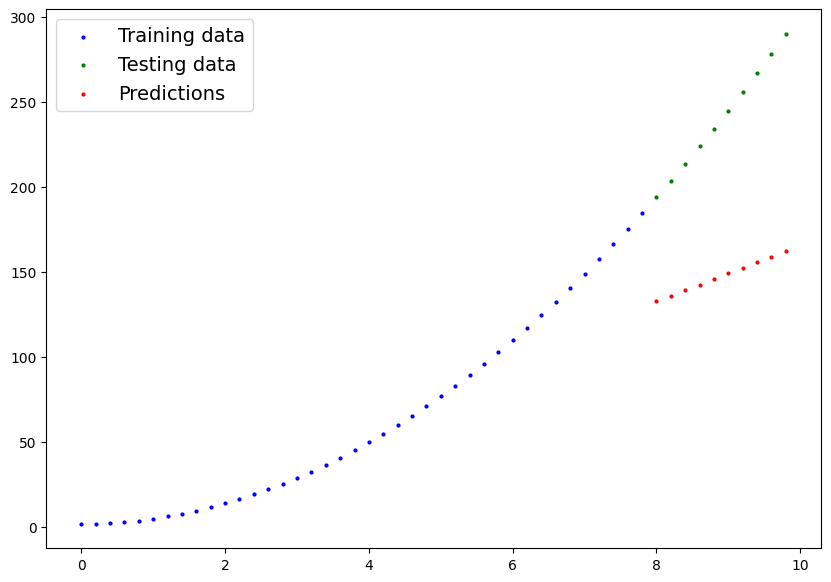

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Using Dataset 2

In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


Shape of X and y confirms correct tensor conversion

Train-Test Split

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

Confirmed dataset is properly split into training and testing sets

Data Visualization Function

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

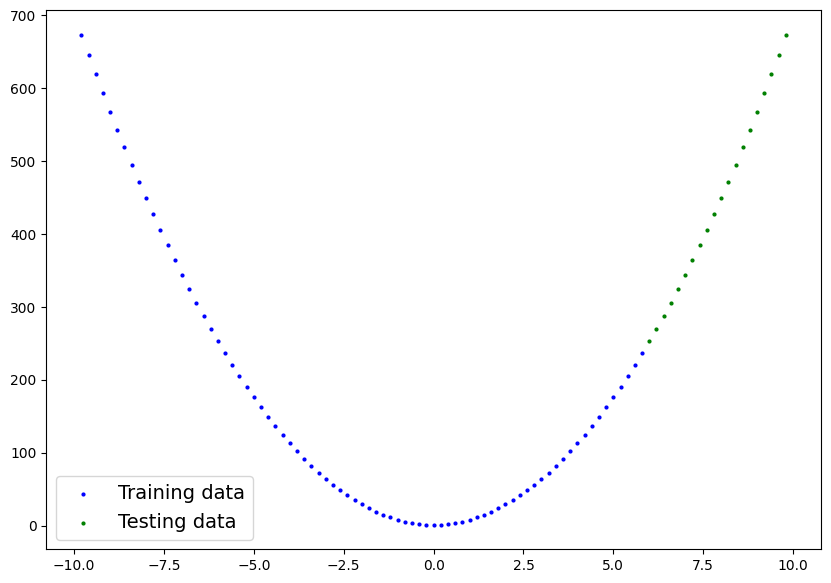

In [ ]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function:
Plots training data (blue),
Plots test data (green),
Optionally plots predictions (red)

Output:
Scatter plot showing dataset distribution
Helps visually understand pattern (quadratic curve)



## Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation:
These are learnable parameters

Initialized randomly

Updated during training using gradient descent

In [ ]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [ ]:
model_0 = LinearRegressionNN()

In [ ]:
print(model_0.linear.weight.dtype)
print(model_0.linear.bias.dtype)

torch.float32
torch.float32


In [ ]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289]])

Explanation:

Makes predictions without gradient tracking

Used for evaluation only

Output:

Predictions are inaccurate initially

Red scatter plot does not match real data

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289],
        [6.1818],
        [6.3347],
        [6.4876],
        [6.6405],
        [6.7934],
        [6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579],
        [7.7109],
        [7.8638],
        [8.0167],
        [8.1696],
        [8.3225]])


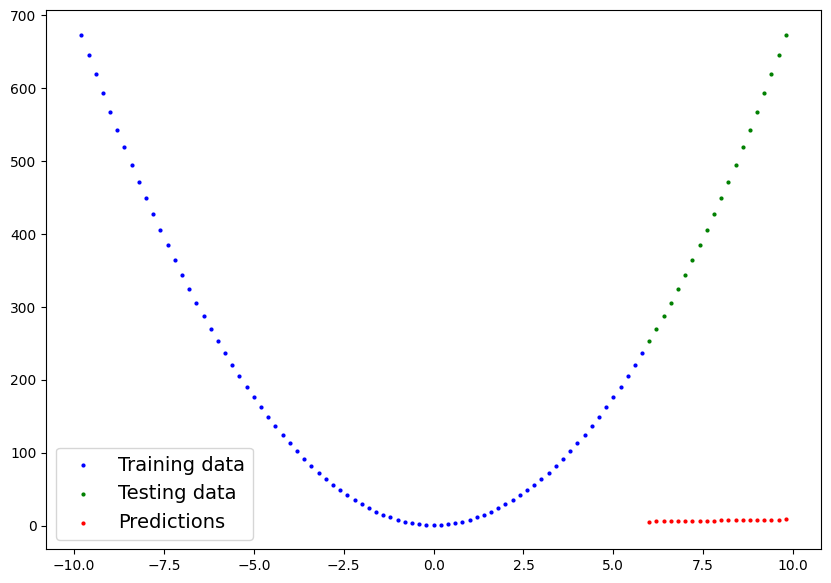

In [ ]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [ ]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 175.299072265625 | MAE Test Loss: 440.4580993652344 
Epoch: 10 | MAE Train Loss: 174.799072265625 | MAE Test Loss: 441.9381408691406 
Epoch: 20 | MAE Train Loss: 174.30055236816406 | MAE Test Loss: 443.41912841796875 
Epoch: 30 | MAE Train Loss: 173.80557250976562 | MAE Test Loss: 444.9017028808594 
Epoch: 40 | MAE Train Loss: 173.31057739257812 | MAE Test Loss: 446.3841857910156 
Epoch: 50 | MAE Train Loss: 172.8198699951172 | MAE Test Loss: 447.86572265625 
Epoch: 60 | MAE Train Loss: 172.3340301513672 | MAE Test Loss: 449.3526306152344 
Epoch: 70 | MAE Train Loss: 171.84866333007812 | MAE Test Loss: 450.8402404785156 
Epoch: 80 | MAE Train Loss: 171.36326599121094 | MAE Test Loss: 452.32781982421875 
Epoch: 90 | MAE Train Loss: 170.87786865234375 | MAE Test Loss: 453.8154296875 
Epoch: 100 | MAE Train Loss: 170.4003143310547 | MAE Test Loss: 455.29754638671875 
Epoch: 110 | MAE Train Loss: 169.92359924316406 | MAE Test Loss: 456.7796936035156 
Epoch: 120 |

Output:

Loss decreases over time

Model gradually learns correct curve

Loss Curve Visualization

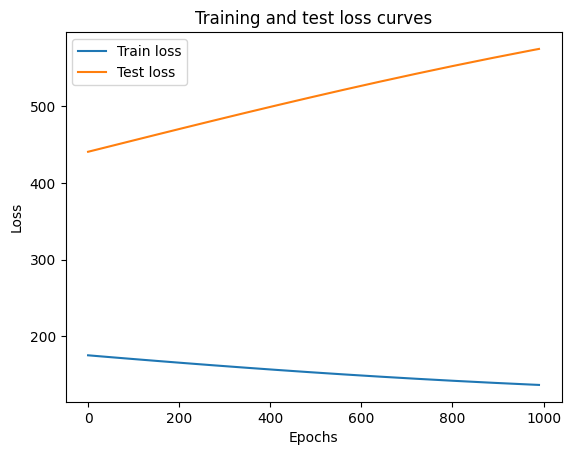

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

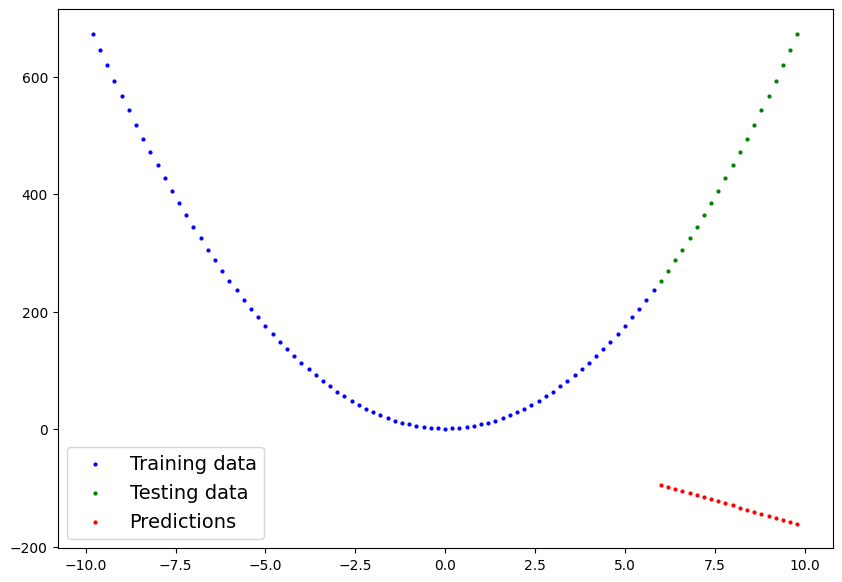

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### Using Dataset 3

In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'linear-regression-data1.csv')
df.head(6)

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


Shape of X and y confirms correct tensor conversion

Train-Test Split

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

Confirmed dataset is properly split into training and testing sets

Data Visualization Function

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

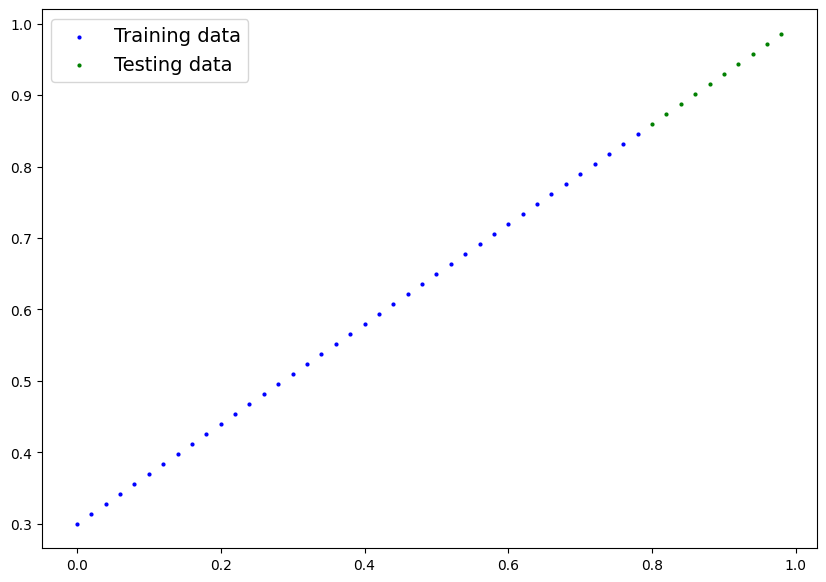

In [ ]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function:
Plots training data (blue),
Plots test data (green),
Optionally plots predictions (red)

Output:
Scatter plot showing dataset distribution
Helps visually understand pattern (quadratic curve)



## Algorithm Selection

We define a linear regression model:
y = wx + b

This model is suitable because the dataset shows a straight-line relationship between input and output variables.

In [ ]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [ ]:
model_0 = LinearRegressionNN()
print(model_0.linear.weight.dtype)
print(model_0.linear.bias.dtype)

torch.float32
torch.float32


In [ ]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028]])

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028],
        [1.5181],
        [1.5334],
        [1.5487],
        [1.5640],
        [1.5793]])


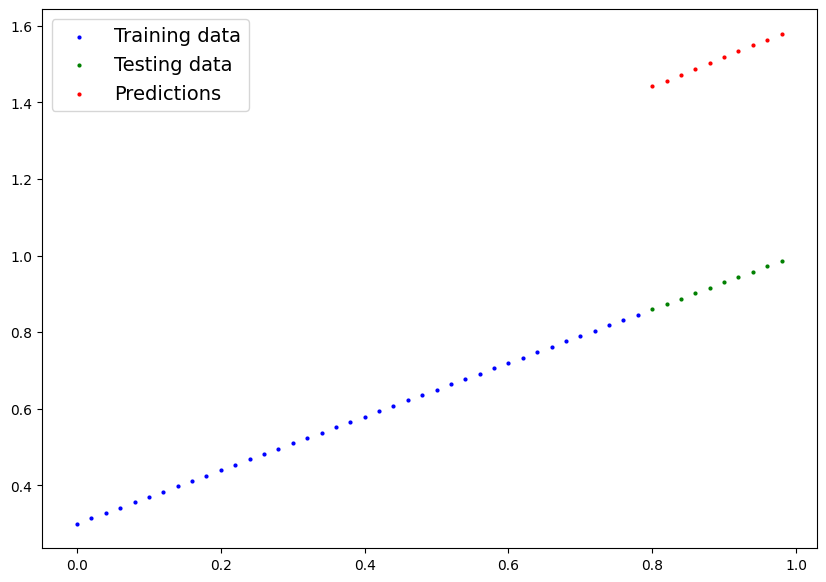

In [ ]:
plot_predictions(predictions=y_preds)

Explanation:

Makes predictions without gradient tracking

Used for evaluation only

Output:

Initial predictions are untrained and do not align well with the actual data distribution.

### Loss Function Selection

In [ ]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.5551779866218567 | MAE Test Loss: 0.5739762187004089 
Epoch: 10 | MAE Train Loss: 0.4399680495262146 | MAE Test Loss: 0.4392663538455963 
Epoch: 20 | MAE Train Loss: 0.3247582018375397 | MAE Test Loss: 0.30455654859542847 
Epoch: 30 | MAE Train Loss: 0.20954832434654236 | MAE Test Loss: 0.16984674334526062 
Epoch: 40 | MAE Train Loss: 0.09433844685554504 | MAE Test Loss: 0.03513689711689949 
Epoch: 50 | MAE Train Loss: 0.023886388167738914 | MAE Test Loss: 0.04784906655550003 
Epoch: 60 | MAE Train Loss: 0.0199567973613739 | MAE Test Loss: 0.04580312222242355 
Epoch: 70 | MAE Train Loss: 0.016517987474799156 | MAE Test Loss: 0.0375305712223053 
Epoch: 80 | MAE Train Loss: 0.013089170679450035 | MAE Test Loss: 0.029944902285933495 
Epoch: 90 | MAE Train Loss: 0.009653178043663502 | MAE Test Loss: 0.02167237363755703 
Epoch: 100 | MAE Train Loss: 0.006215679459273815 | MAE Test Loss: 0.014086711220443249 
Epoch: 110 | MAE Train Loss: 0.002787243574857712 | MA

Output:

Model gradually learns the linear relationship between input and output variables by adjusting slope and intercept.

Loss Curve Visualization

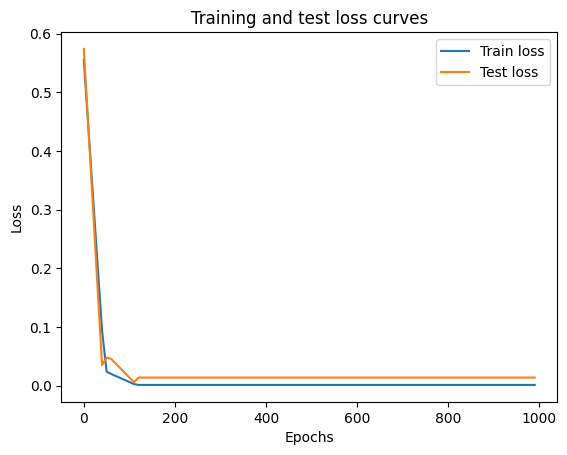

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

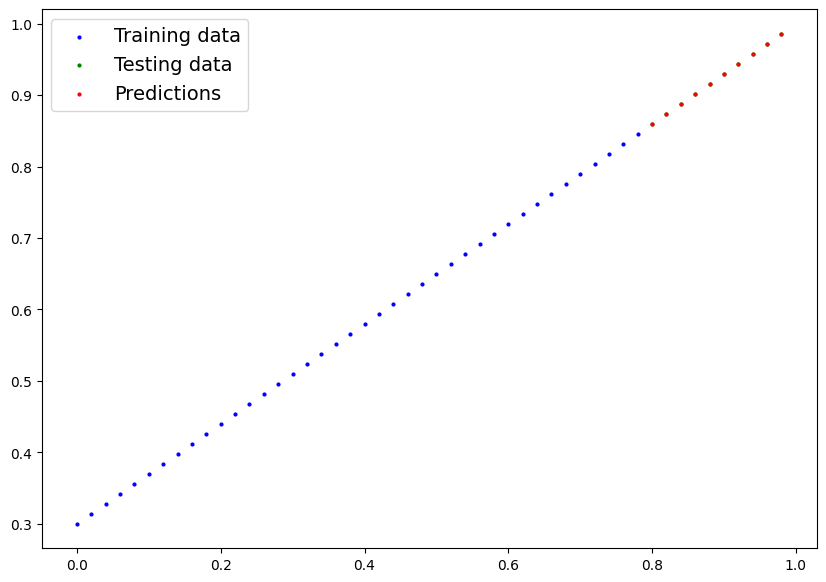

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

Red points (predictions) align closely with actual data.
Indicates successful learning of the linear relationship between variables.

Among the three datasets provided in Lab 4, only linear-regression-data1.csv is suitable for training with the given LinearRegressionNN model. The model's simple linear architecture is capable of learning datasets with linear relationships but is insufficient for datasets containing nonlinear patterns. To effectively learn from assignment-data.csv and assignment-data2.csv, a neural network with additional hidden layers and nonlinear activation functions would be necessary.

## Task 2

## Using LinearRegressionNN 

### 1. Using Dataset binary_classification_moons.csv

In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'binary_classification_moons.csv')
df.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 10 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 20 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 30 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 40 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 50 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 60 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 70 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 80 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 90 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 100 | MAE Train Loss: 0.0012645035749301314 | MAE Test Loss: 0.013801807537674904 
Epoch: 110 | MAE Trai

Output:

Loss decreases over time

Model gradually learns correct curve

Loss Curve Visualization

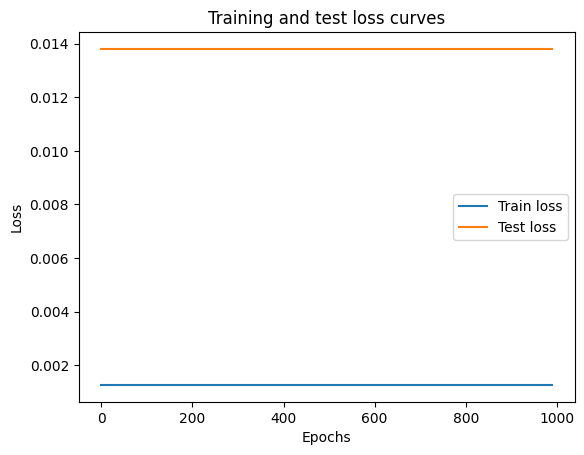

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

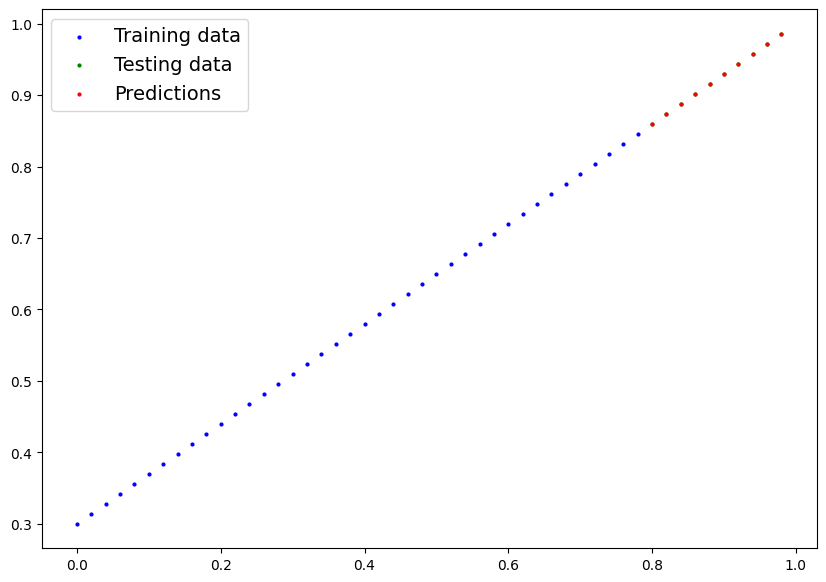

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

Red points (predictions) align closely with actual data
Indicates successful learning of quadratic relationship

### Using Dataset 2

In [ ]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0'

torch: Core PyTorch library for tensor computation

matplotlib: Used for visualization

nn: Contains neural network building blocks

In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# 1. Data Preparation

In [ ]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment-data2.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [ ]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


Shape of X and y confirms correct tensor conversion

Train-Test Split

In [ ]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

Confirmed dataset is properly split into training and testing sets

Data Visualization Function

In [ ]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

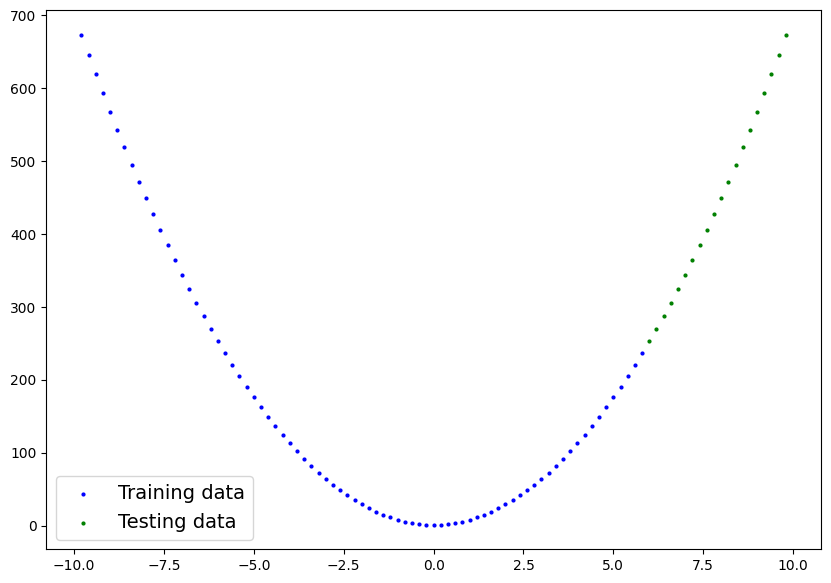

In [ ]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

This function:
Plots training data (blue),
Plots test data (green),
Optionally plots predictions (red)

Output:
Scatter plot showing dataset distribution
Helps visually understand pattern (quadratic curve)



## Algorithm Selection

We define a custom model:

y=ax2+bx+c

Explanation:
These are learnable parameters

Initialized randomly

Updated during training using gradient descent

In [ ]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [ ]:
model_0 = LinearRegressionNN()

In [ ]:
print(model_0.linear.weight.dtype)
print(model_0.linear.bias.dtype)

torch.float32
torch.float32


In [ ]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289]])

Explanation:

Makes predictions without gradient tracking

Used for evaluation only

Output:

Predictions are inaccurate initially

Red scatter plot does not match real data

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289],
        [6.1818],
        [6.3347],
        [6.4876],
        [6.6405],
        [6.7934],
        [6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579],
        [7.7109],
        [7.8638],
        [8.0167],
        [8.1696],
        [8.3225]])


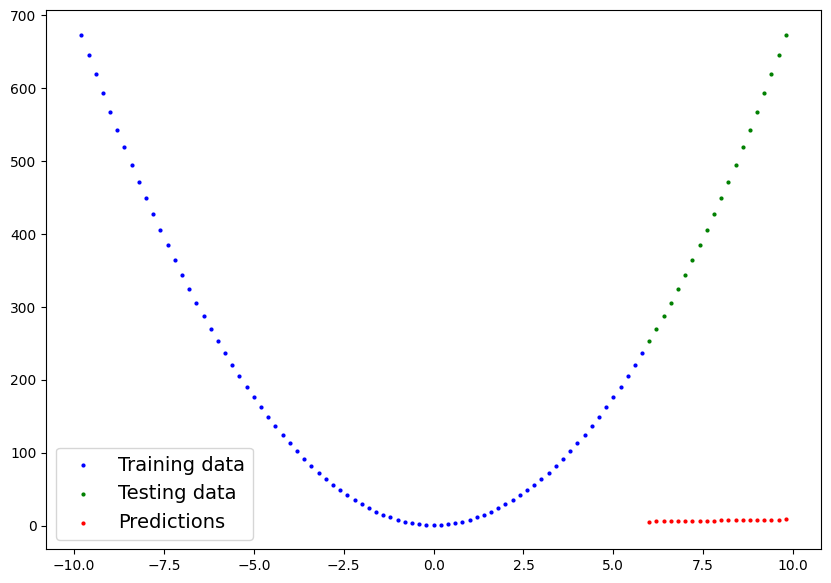

In [ ]:
plot_predictions(predictions=y_preds)

### Loss Function Selection

In [ ]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

Explanation:

Loss Function (MAE) measures error

SGD optimizer updates parameters to reduce error

In [ ]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 175.299072265625 | MAE Test Loss: 440.4580993652344 
Epoch: 10 | MAE Train Loss: 174.799072265625 | MAE Test Loss: 441.9381408691406 
Epoch: 20 | MAE Train Loss: 174.30055236816406 | MAE Test Loss: 443.41912841796875 
Epoch: 30 | MAE Train Loss: 173.80557250976562 | MAE Test Loss: 444.9017028808594 
Epoch: 40 | MAE Train Loss: 173.31057739257812 | MAE Test Loss: 446.3841857910156 
Epoch: 50 | MAE Train Loss: 172.8198699951172 | MAE Test Loss: 447.86572265625 
Epoch: 60 | MAE Train Loss: 172.3340301513672 | MAE Test Loss: 449.3526306152344 
Epoch: 70 | MAE Train Loss: 171.84866333007812 | MAE Test Loss: 450.8402404785156 
Epoch: 80 | MAE Train Loss: 171.36326599121094 | MAE Test Loss: 452.32781982421875 
Epoch: 90 | MAE Train Loss: 170.87786865234375 | MAE Test Loss: 453.8154296875 
Epoch: 100 | MAE Train Loss: 170.4003143310547 | MAE Test Loss: 455.29754638671875 
Epoch: 110 | MAE Train Loss: 169.92359924316406 | MAE Test Loss: 456.7796936035156 
Epoch: 120 |

Output:

Loss decreases over time

Model gradually learns correct curve

Loss Curve Visualization

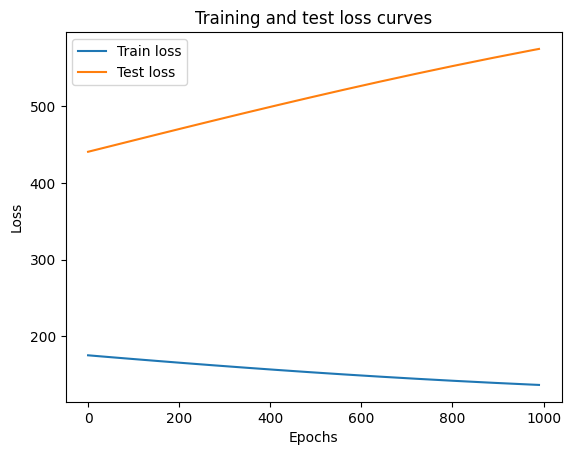

In [ ]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

Explanation:

Shows training vs testing error

Helps verify model learning

Output:

Curve decreases → model is learning

Stable convergence → good fit

Final Prediction Visualization

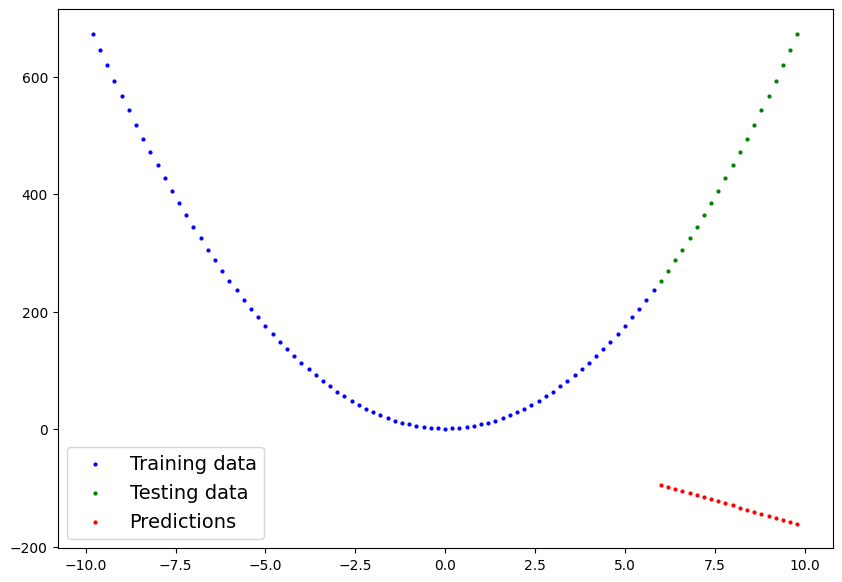

In [ ]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## Using ModelV0

### Data Retreival and Collection



In [ ]:
import pandas as pd

data = pd.read_csv(r'binary_classification_moons.csv')
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


### Data Cleaning 

In [ ]:
data.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


Here, the data is clean, so no additional preprocessing steps are required.



### Feature Design

In NN, feature desisn is an automatic step. 

### Algorithm Selection

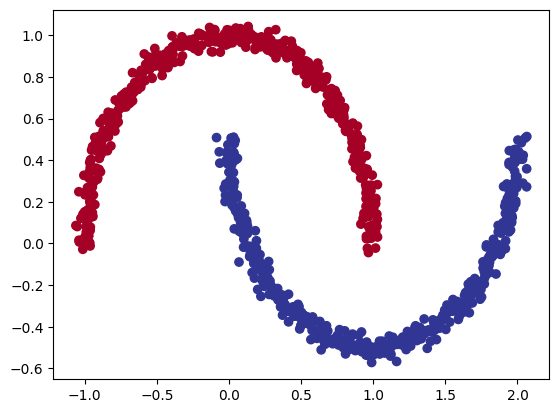

In [ ]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=data.X1, 
            y=data.X2, 
            c=data.label, 
            cmap=plt.cm.RdYlBu
            );

In [ ]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [ ]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [ ]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [ ]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)
    
    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model = model_0

In [ ]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1435],
        [-0.0799],
        [-0.1176],
        [-0.0775],
        [-0.0713],
        [-0.0593],
        [-0.0908],
        [-0.0988],
        [-0.1263],
        [-0.0826]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### Loss Function Selection

In [ ]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

In [ ]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.1435],
        [-0.0799],
        [-0.1176],
        [-0.0775],
        [-0.0713]], grad_fn=<SliceBackward0>)

In [ ]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4642],
        [0.4800],
        [0.4706],
        [0.4806],
        [0.4822]], grad_fn=<SigmoidBackward0>)

In [ ]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Model Learning

In [ ]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device) 


### Model Evaluation

In [ ]:
from utils import train_and_test_loop

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

Epoch: 0 | Loss: 0.69395, Accuracy: 50.00% | Test loss: 0.68147, Test acc: 58.50%
Epoch: 10 | Loss: 0.57149, Accuracy: 79.12% | Test loss: 0.57350, Test acc: 75.00%
Epoch: 20 | Loss: 0.48652, Accuracy: 81.12% | Test loss: 0.49746, Test acc: 79.00%
Epoch: 30 | Loss: 0.42603, Accuracy: 82.00% | Test loss: 0.44278, Test acc: 80.50%
Epoch: 40 | Loss: 0.38463, Accuracy: 82.25% | Test loss: 0.40451, Test acc: 81.00%
Epoch: 50 | Loss: 0.35657, Accuracy: 82.88% | Test loss: 0.37765, Test acc: 81.50%
Epoch: 60 | Loss: 0.33707, Accuracy: 83.12% | Test loss: 0.35814, Test acc: 81.50%
Epoch: 70 | Loss: 0.32288, Accuracy: 83.75% | Test loss: 0.34328, Test acc: 81.50%
Epoch: 80 | Loss: 0.31201, Accuracy: 84.00% | Test loss: 0.33141, Test acc: 82.00%
Epoch: 90 | Loss: 0.30329, Accuracy: 84.75% | Test loss: 0.32152, Test acc: 83.00%


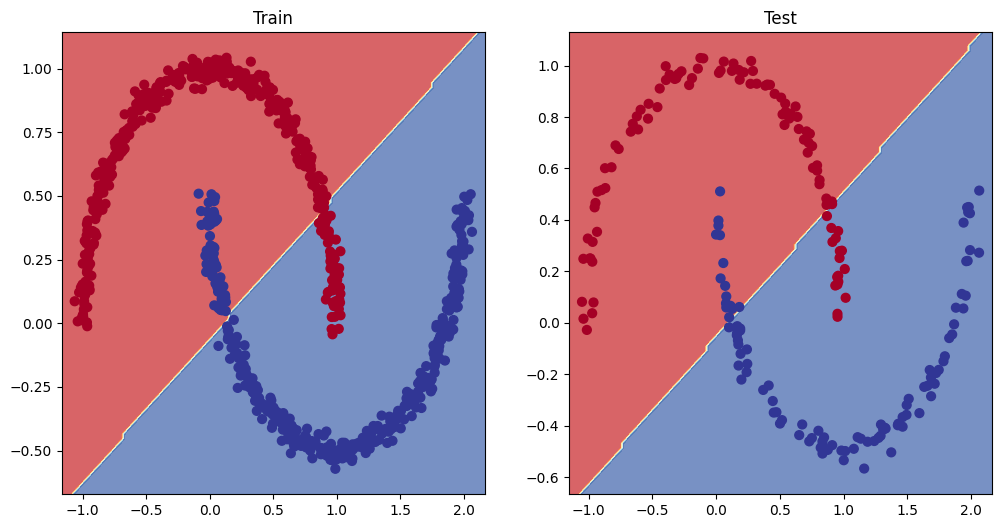

In [ ]:
from utils import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In machine learning terms, our model is `underfitting`, meaning it's not learning predictive patterns from the data.

Let's also plot the loss graph: 


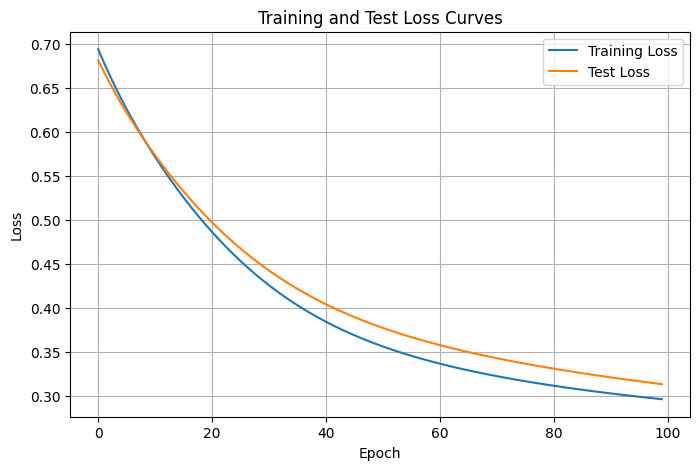

In [ ]:

import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

## Improving an Underfitting Model

Let’s try to address our model’s **underfitting** problem.

Focusing specifically on the **model itself** (not the data), there are several common techniques we can use to increase its capacity to learn more complex patterns.

### Model Improvement Techniques

| Model improvement technique* | What does it do? |
| ----- | ----- |
| **Add more layers** | Each additional layer can increase the model’s ability to learn hierarchical and more complex patterns. Models with more layers are often described as being *deeper*. |
| **Add more hidden units** | Increasing the number of hidden units in a layer can improve the model’s representational power. Models with more units per layer are often described as being *wider*. |
| **Train for longer (more epochs)** | Giving the model more passes over the training data can allow it to learn patterns it may not have captured initially. |

The rest of the methods will be discussed in the next .ipynb file. 

> **Note:** Because these settings are chosen *before* training and tuned manually, they are referred to as **hyperparameters**.

---

### Improving the Model

To increase the model’s learning capacity, we’ll make the following changes:

- Add an extra hidden layer  
- Increase the number of hidden units from **5 → 10**  
- Train for longer, increasing epochs from **100 → 1000**

We’ll follow the same modeling steps as before, but with these updated hyperparameters, and then evaluate whether these changes help reduce underfitting and improve performance.


In [ ]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
model = model_1
epochs = 1000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.70134, Test acc: 45.50%
Epoch: 10 | Loss: 0.58674, Accuracy: 79.62% | Test loss: 0.58552, Test acc: 78.00%
Epoch: 20 | Loss: 0.47594, Accuracy: 79.62% | Test loss: 0.48700, Test acc: 77.00%
Epoch: 30 | Loss: 0.39832, Accuracy: 81.00% | Test loss: 0.41841, Test acc: 77.00%
Epoch: 40 | Loss: 0.35499, Accuracy: 81.62% | Test loss: 0.37773, Test acc: 78.00%
Epoch: 50 | Loss: 0.32886, Accuracy: 82.62% | Test loss: 0.35055, Test acc: 80.50%
Epoch: 60 | Loss: 0.31010, Accuracy: 83.75% | Test loss: 0.32940, Test acc: 82.00%
Epoch: 70 | Loss: 0.29513, Accuracy: 84.75% | Test loss: 0.31171, Test acc: 83.50%
Epoch: 80 | Loss: 0.28276, Accuracy: 85.00% | Test loss: 0.29670, Test acc: 85.50%
Epoch: 90 | Loss: 0.27260, Accuracy: 85.62% | Test loss: 0.28413, Test acc: 86.50%
Epoch: 100 | Loss: 0.26443, Accuracy: 86.25% | Test loss: 0.27384, Test acc: 87.50%
Epoch: 110 | Loss: 0.25803, Accuracy: 87.00% | Test loss: 0.26561, Test acc: 87.50%
Epo

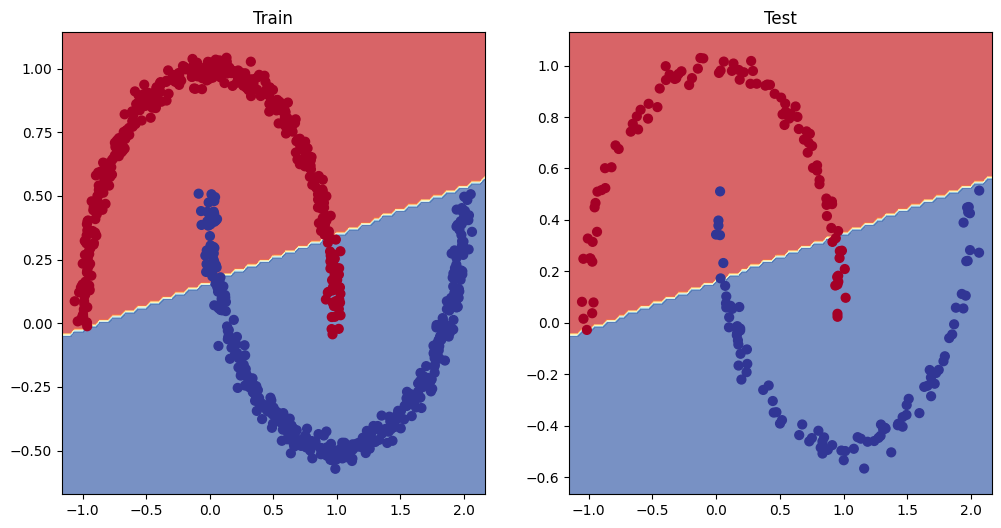

In [ ]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

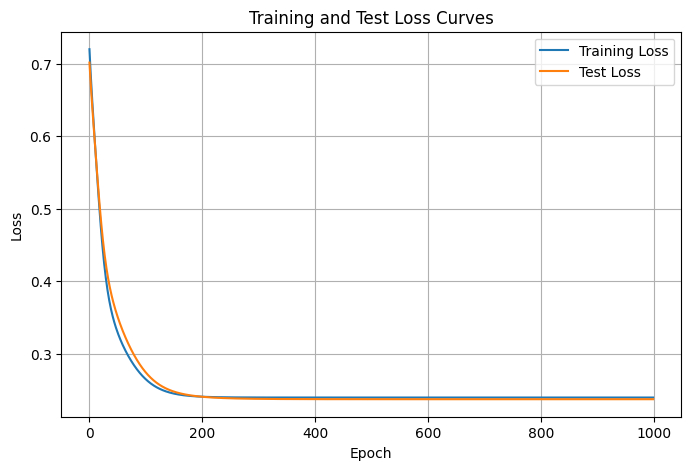

In [ ]:
plot_loss_curves(train_losses, test_losses)

In [ ]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    plt.figure(figsize=(10, 7))

    # Training data
    plt.scatter(train_data[:, 0],
                train_data[:, 1],
                c=train_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Train")

    # Test data
    plt.scatter(test_data[:, 0],
                test_data[:, 1],
                c=test_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Test")

    if predictions is not None:
        plt.scatter(test_data[:, 0],
                    test_data[:, 1],
                    c=predictions.detach().numpy(),
                    cmap=plt.cm.RdYlBu,
                    marker="x",
                    s=80,
                    label="Predictions")

    plt.legend()
    plt.show()

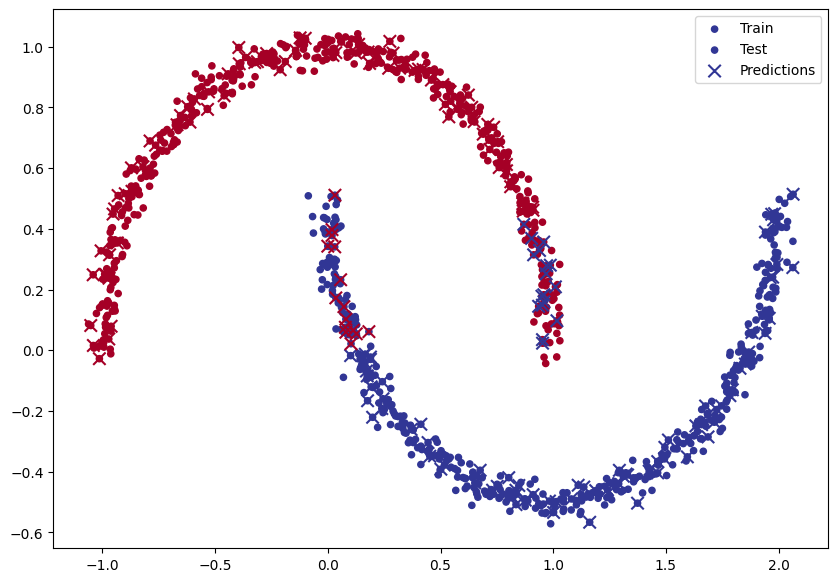

In [ ]:
y_preds = model_0(X_test)
y_preds = torch.round(torch.sigmoid(y_preds))

plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=y_preds
)


## Task 3

In [1]:
import pandas as pd

path = r'binary_classification_moons.csv'

data = pd.read_csv(path)
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [2]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [3]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

/var/folders/7s/5gnsvf394r55wlyjssk82y840000gn/T/ipykernel_7176/1521810368.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(800, 200, 800, 200)

In [4]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
# Build model with non-linear activation function
from torch import nn
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = ModelV2().to(device)
print(model_2)

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


In [6]:
from utils import train_and_test_loop, plot_decision_boundary
import matplotlib.pyplot as plt

Epoch: 0 | Loss: 0.66844, Accuracy: 75.50% | Test loss: 0.66794, Test acc: 77.50%
Epoch: 10 | Loss: 0.63246, Accuracy: 80.00% | Test loss: 0.63406, Test acc: 80.00%
Epoch: 20 | Loss: 0.59203, Accuracy: 81.25% | Test loss: 0.59627, Test acc: 80.00%
Epoch: 30 | Loss: 0.54726, Accuracy: 81.75% | Test loss: 0.55471, Test acc: 81.00%
Epoch: 40 | Loss: 0.50112, Accuracy: 81.75% | Test loss: 0.51162, Test acc: 81.50%
Epoch: 50 | Loss: 0.45672, Accuracy: 82.75% | Test loss: 0.46907, Test acc: 83.50%
Epoch: 60 | Loss: 0.41553, Accuracy: 83.75% | Test loss: 0.42859, Test acc: 84.50%
Epoch: 70 | Loss: 0.37893, Accuracy: 84.50% | Test loss: 0.39182, Test acc: 85.00%
Epoch: 80 | Loss: 0.34762, Accuracy: 85.00% | Test loss: 0.35976, Test acc: 85.50%
Epoch: 90 | Loss: 0.32193, Accuracy: 86.00% | Test loss: 0.33290, Test acc: 87.00%


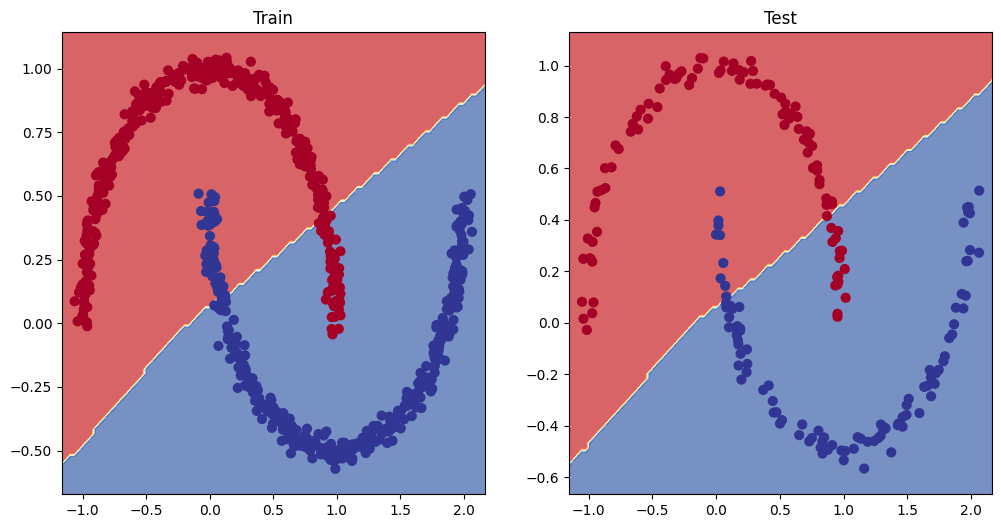

In [7]:
model = model_2
epochs = 100

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

Epoch: 0 | Loss: 0.69529, Accuracy: 50.00% | Test loss: 0.69267, Test acc: 50.00%
Epoch: 10 | Loss: 0.66699, Accuracy: 51.62% | Test loss: 0.66596, Test acc: 67.00%
Epoch: 20 | Loss: 0.63903, Accuracy: 82.00% | Test loss: 0.64008, Test acc: 79.00%
Epoch: 30 | Loss: 0.60484, Accuracy: 81.62% | Test loss: 0.60779, Test acc: 76.50%
Epoch: 40 | Loss: 0.56175, Accuracy: 81.38% | Test loss: 0.56644, Test acc: 77.00%
Epoch: 50 | Loss: 0.51073, Accuracy: 82.38% | Test loss: 0.51772, Test acc: 78.00%
Epoch: 60 | Loss: 0.45730, Accuracy: 83.50% | Test loss: 0.46689, Test acc: 78.50%
Epoch: 70 | Loss: 0.40848, Accuracy: 84.00% | Test loss: 0.42007, Test acc: 80.00%
Epoch: 80 | Loss: 0.36850, Accuracy: 84.38% | Test loss: 0.38111, Test acc: 81.00%
Epoch: 90 | Loss: 0.33776, Accuracy: 85.25% | Test loss: 0.35039, Test acc: 82.00%
Epoch: 100 | Loss: 0.31434, Accuracy: 85.62% | Test loss: 0.32616, Test acc: 83.50%
Epoch: 110 | Loss: 0.29643, Accuracy: 86.25% | Test loss: 0.30697, Test acc: 84.50%
Epo

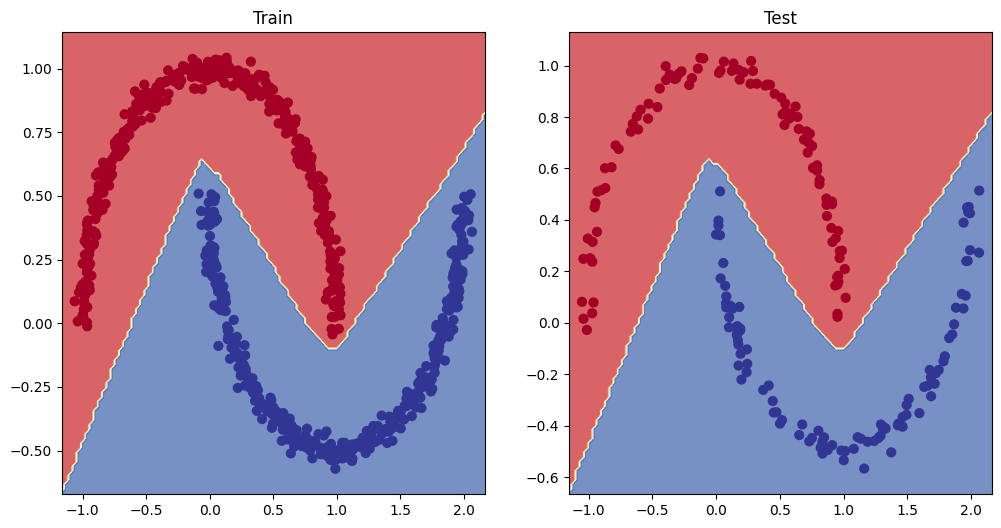

In [8]:
epochs = 1000
model = ModelV2().to(device) # reset model
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

Epoch: 0 | Loss: 0.68212, Accuracy: 50.00% | Test loss: 0.68119, Test acc: 50.00%
Epoch: 10 | Loss: 0.66162, Accuracy: 56.12% | Test loss: 0.66127, Test acc: 68.50%
Epoch: 20 | Loss: 0.63623, Accuracy: 88.88% | Test loss: 0.63632, Test acc: 87.50%
Epoch: 30 | Loss: 0.60138, Accuracy: 87.12% | Test loss: 0.60221, Test acc: 86.00%
Epoch: 40 | Loss: 0.55463, Accuracy: 86.50% | Test loss: 0.55741, Test acc: 83.50%
Epoch: 50 | Loss: 0.50406, Accuracy: 86.38% | Test loss: 0.50988, Test acc: 83.00%
Epoch: 60 | Loss: 0.45529, Accuracy: 86.25% | Test loss: 0.46411, Test acc: 83.50%
Epoch: 70 | Loss: 0.41228, Accuracy: 86.12% | Test loss: 0.42300, Test acc: 83.50%
Epoch: 80 | Loss: 0.37583, Accuracy: 86.62% | Test loss: 0.38736, Test acc: 86.00%
Epoch: 90 | Loss: 0.34527, Accuracy: 86.75% | Test loss: 0.35697, Test acc: 86.00%
Epoch: 100 | Loss: 0.32005, Accuracy: 86.62% | Test loss: 0.33154, Test acc: 87.00%
Epoch: 110 | Loss: 0.29969, Accuracy: 87.12% | Test loss: 0.31068, Test acc: 87.50%
Epo

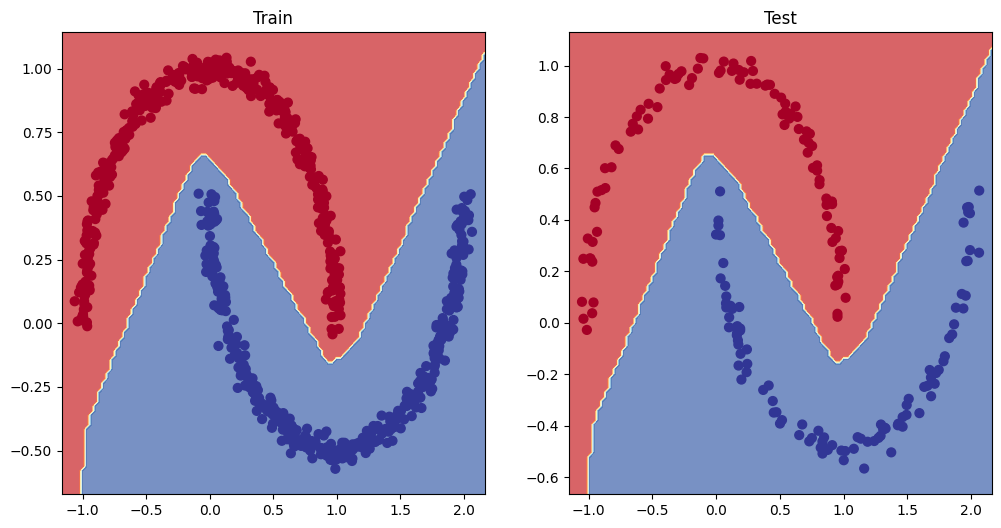

In [9]:
model = ModelV2().to(device) # reset model
epochs = 1500
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)
# plot_loss_curves(train_losses, test_losses)

In [10]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    plt.figure(figsize=(10, 7))

    # Training data
    plt.scatter(train_data[:, 0],
                train_data[:, 1],
                c=train_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Train")

    # Test data
    plt.scatter(test_data[:, 0],
                test_data[:, 1],
                c=test_labels,
                cmap=plt.cm.RdYlBu,
                s=20,
                label="Test")

    if predictions is not None:
        plt.scatter(test_data[:, 0],
                    test_data[:, 1],
                    c=predictions.detach().numpy(),
                    cmap=plt.cm.RdYlBu,
                    marker="x",
                    s=80,
                    label="Predictions")

    plt.legend()
    plt.show()

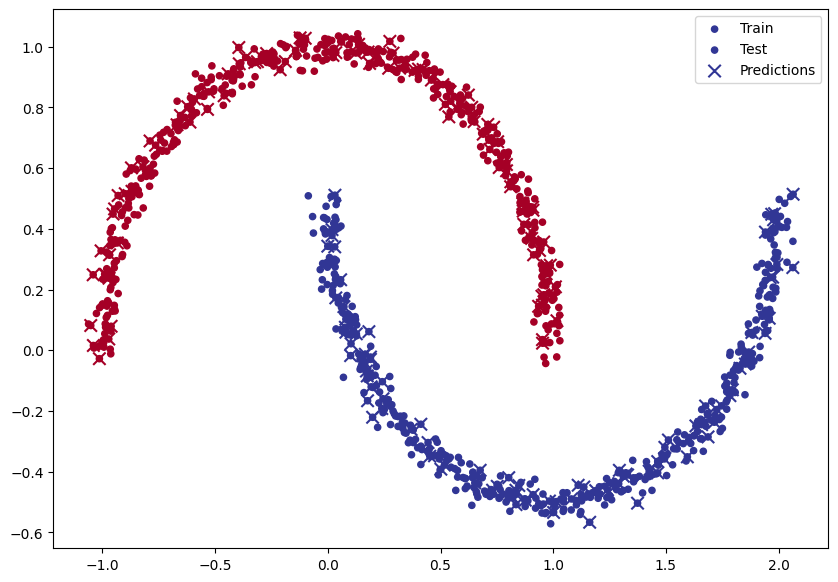

In [11]:
y_preds = model(X_test)
y_preds = torch.round(torch.sigmoid(y_preds))
plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=y_preds
    
)

### Discussion

This lab session explored neural network implementation in PyTorch across three tasks. Task 1 used a linear regression model on three datasets, revealing that while it worked perfectly for linear data, it failed on quadratic patterns due to architectural limitations. Task 2 applied classification models to moon-shaped data, demonstrating that models without non-linear activations (ModelV0, V1) underfit, while ModelV2 with ReLU successfully learned the decision boundary. Task 3 optimized ModelV2 across different epochs (100, 1000, 1500), confirming that sufficient training time is essential for convergence. Throughout all tasks, we utilized MAE/BCE loss functions, SGD optimization, and evaluated performance through loss curves and prediction visualizations.



### Conclusion

This laboratory session successfully demonstrated fundamental neural network concepts in PyTorch, including linear regression, binary classification, and the critical roles of non-linear activation functions and hyperparameter tuning. The experiments reinforced that model architecture must align with data complexity—linear models suit linear data, while non-linear problems require deeper networks with activation functions. Proper selection of layers, hidden units, and training epochs proved essential for avoiding underfitting and achieving optimal performance.